In [1]:
using LinearAlgebra
using CSV, DataFrames, Plots, LaTeXStrings
include("module_mos2_free_ph_plot.jl")
using .exciton

In [2]:
function draw_custom_arrow!(p, x, y, u, v; scale=1.0, head_size=0.15, color=:black, lw=2.0)
    x_end = x + u * scale
    y_end = y + v * scale

    x_end_ind = x + u * scale * 0.9
    y_end_ind = y + v * scale * 0.9

    plot!(p, [x, x_end_ind], [y, y_end_ind], color=color, lw=lw, label=false)

    θ = atan(v, u)
    wing_len = head_size * 0.8

    arrowangle = pi / 8
    x_w1 = x_end - wing_len * cos(θ + arrowangle)
    y_w1 = y_end - wing_len * sin(θ + arrowangle)
    x_w2 = x_end - wing_len * cos(θ - arrowangle)
    y_w2 = y_end - wing_len * sin(θ - arrowangle)

    shape_x = [x_end, x_w1, x_w2, x_end]
    shape_y = [y_end, y_w1, y_w2, y_end]
    plot!(p, Shape(shape_x, shape_y), color=color, linecolor=color, fillcolor=color, label=false)
end

draw_custom_arrow! (generic function with 1 method)

# Fig 1

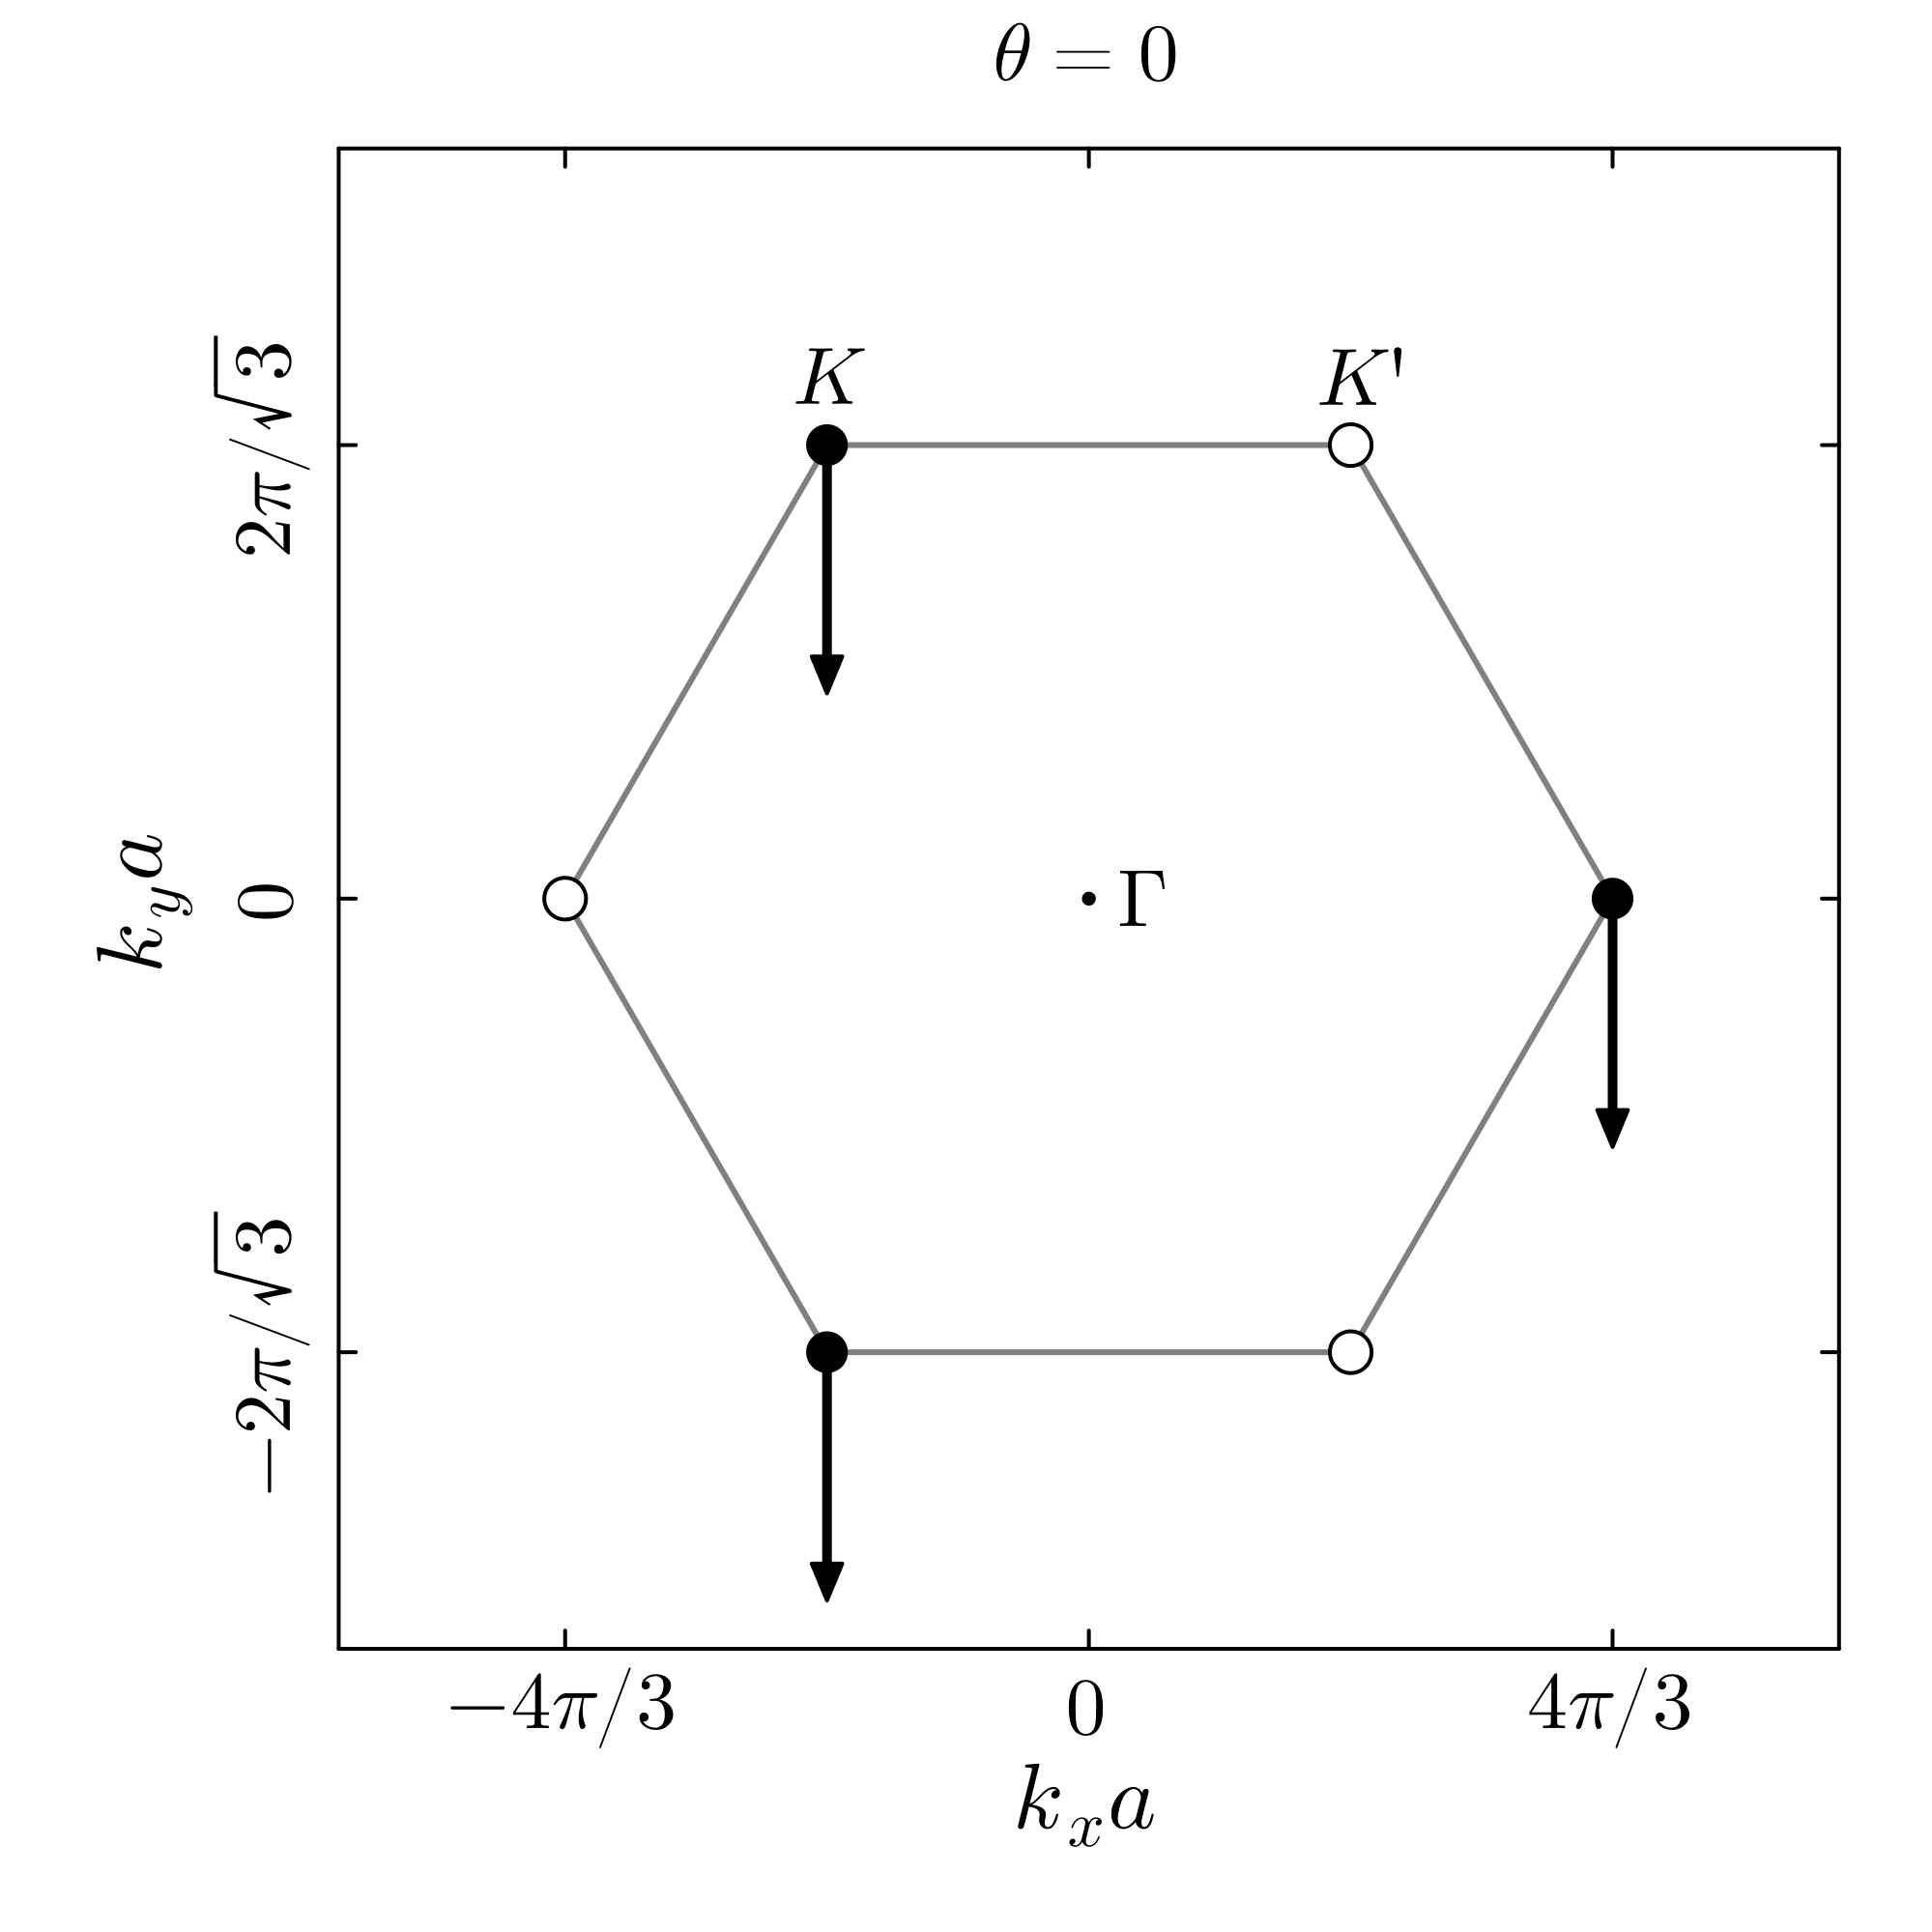

In [3]:
hex_x = [4pi/3, 2pi/3, -2pi/3, -4pi/3, -2pi/3, 2pi/3, 4pi/3]
hex_y = [0, 2pi/sqrt(3), 2pi/sqrt(3), 0, -2pi/sqrt(3), -2pi/sqrt(3), 0]


df = CSV.read("figs3_theta_0.csv", DataFrame)

kx = df.kx_list
ky = df.ky_list
U = df.rx_list
V = df.ry_list;
kx_p=-kx
ky_p=-ky

p = plot(size=(500, 500), aspect_ratio=:equal, dpi=400)

plot!(hex_x, hex_y; lw=1.5, color=:gray, label=false)

# Γ point
scatter!([0.0], [0.0]; markersize=2, markercolor=:black, label=false)
annotate!(0.25, 0.0, text(L"\Gamma", :left, 14))

# shift vectors at K
for i in eachindex(kx)
    draw_custom_arrow!(
        p, kx[i], ky[i], U[i], V[i];
        scale=0.8,
        head_size=0.4,
        color=:black,
        lw=2.5
    )
end

# K points (solid black)
scatter!(kx, ky; markersize=6, markercolor=:black, markerstrokecolor=:black, label=false)

# K' points (empty black circles)
scatter!(kx_p, ky_p; markersize=6, markercolor=:white, markerstrokecolor=:black, label=false)

annotate!(kx[2]-0.25 , ky[2]+0.55 , text(L"K", :left, 14))
annotate!(kx_p[3]-0.25 , ky_p[3] +0.55, text(L"K'", :left, 14))

plot!(
    framestyle=:box,
    grid=false,
    xlims=(-6,6),
    ylims=(-6,6),
    xticks=([-4pi/3,0,4pi/3], [L"-4\pi/3", L"0", L"4\pi/3"]),
    yticks=([-2pi/sqrt(3), 0,  2pi/sqrt(3)], [L"-2\pi/\sqrt{3}",  L"0", L"2\pi/\sqrt{3}"]
),
    tickfontsize=14,
    title=L"\theta=0",
    xlabel=L"k_x a",   
    ylabel=L"k_y a",    
    guidefontsize=16,
    yrotation = 90
)

savefig("fig1.pdf")
display(p)

# Fig2

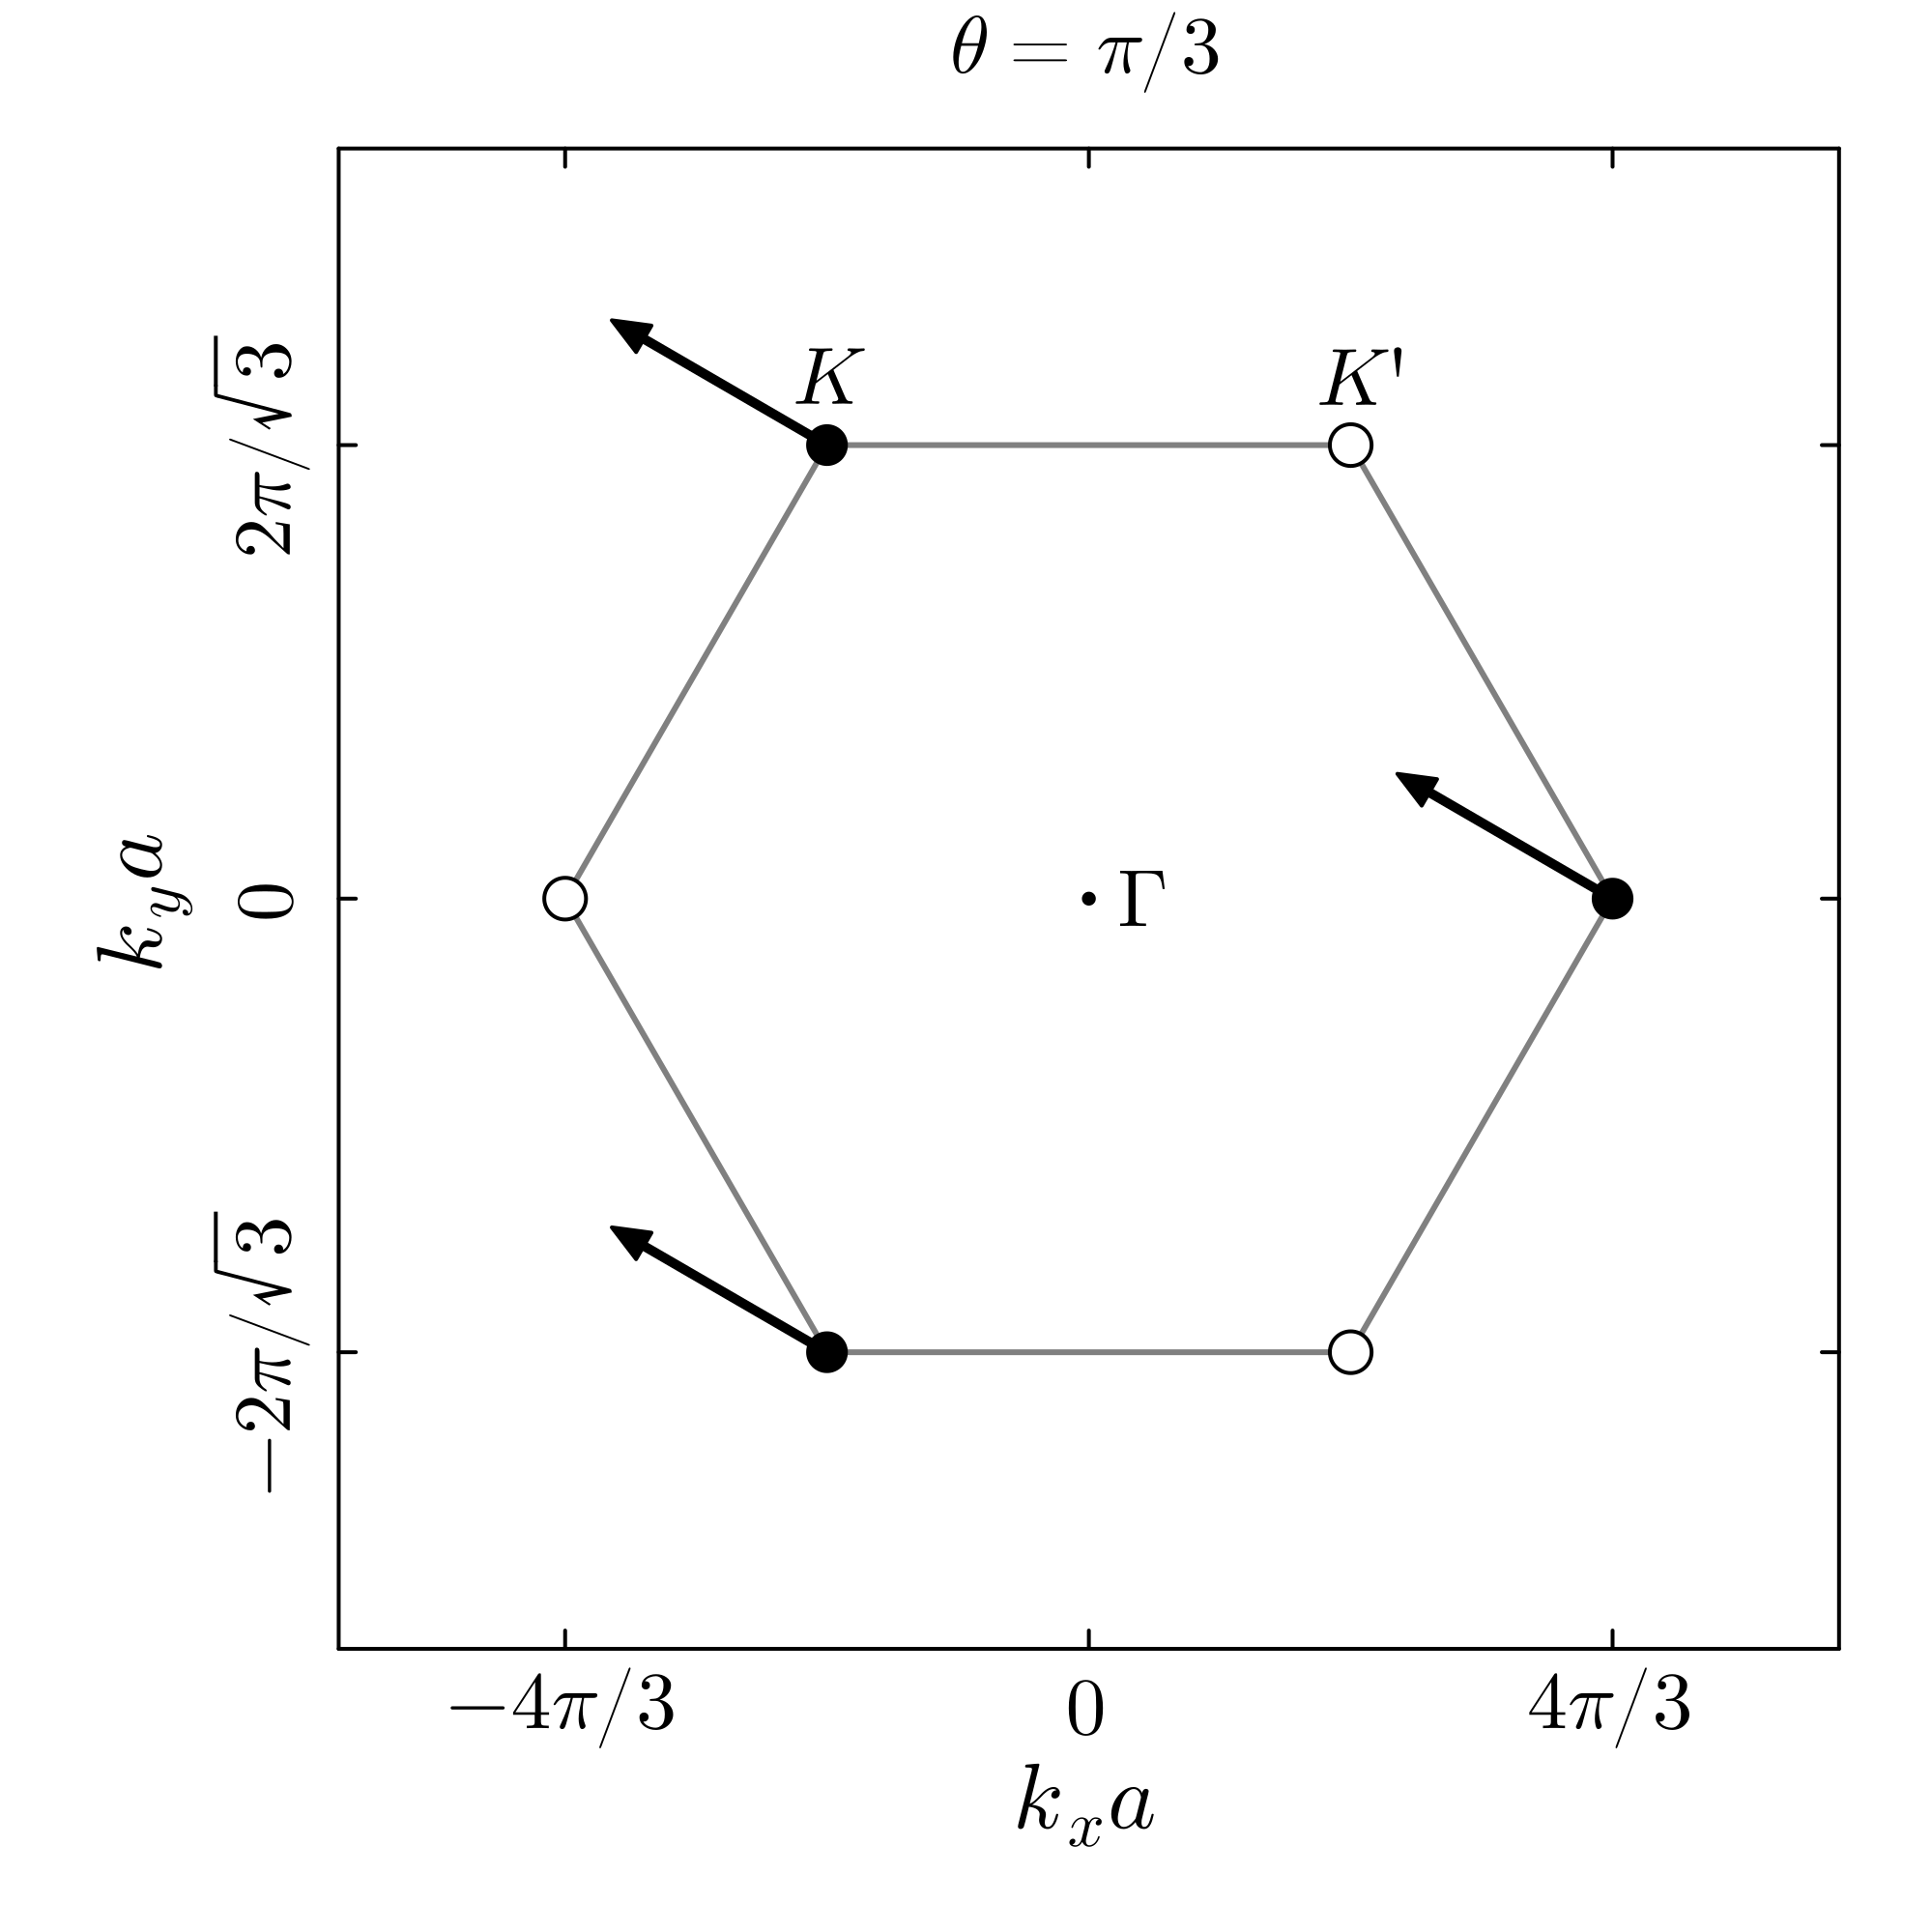

In [4]:
df = CSV.read("figs3_theta_pi_3.csv", DataFrame)

kx = df.kx_list
ky = df.ky_list
U = df.rx_list
V = df.ry_list;
kx_p=-kx
ky_p=-ky

p = plot(size=(500, 500), aspect_ratio=:equal, dpi=400)

plot!(hex_x, hex_y; lw=1.5, color=:gray, label=false)

# Γ point
scatter!([0.0], [0.0]; markersize=2, markercolor=:black, label=false)
annotate!(0.25, 0.0, text(L"\Gamma", :left, 14))

# shift vectors at K
for i in eachindex(kx)
    draw_custom_arrow!(
        p, kx[i], ky[i], U[i], V[i];
        scale=0.8,
        head_size=0.4,
        color=:black,
        lw=2.5
    )
end


scatter!(kx, ky; markersize=6, markercolor=:black, markerstrokecolor=:black, label=false)
scatter!(kx_p, ky_p; markersize=6, markercolor=:white, markerstrokecolor=:black, label=false)

annotate!(kx[2]-0.25 , ky[2]+0.55 , text(L"K", :left, 14))
annotate!(kx_p[3]-0.25 , ky_p[3] +0.55, text(L"K'", :left, 14))

plot!(
    framestyle=:box,
    grid=false,
    xlims=(-6,6),
    ylims=(-6,6),
    xticks=([-4pi/3,0,4pi/3], [L"-4\pi/3", L"0", L"4\pi/3"]),
    yticks=([-2pi/sqrt(3), 0,  2pi/sqrt(3)], [L"-2\pi/\sqrt{3}",  L"0", L"2\pi/\sqrt{3}"]
),
    tickfontsize=14,
    title=L"\theta=\pi/3",
    xlabel=L"k_x a",   
    ylabel=L"k_y a",    
    guidefontsize=16,
    yrotation = 90
)

savefig("fig2.pdf")
display(p)

# Fig3

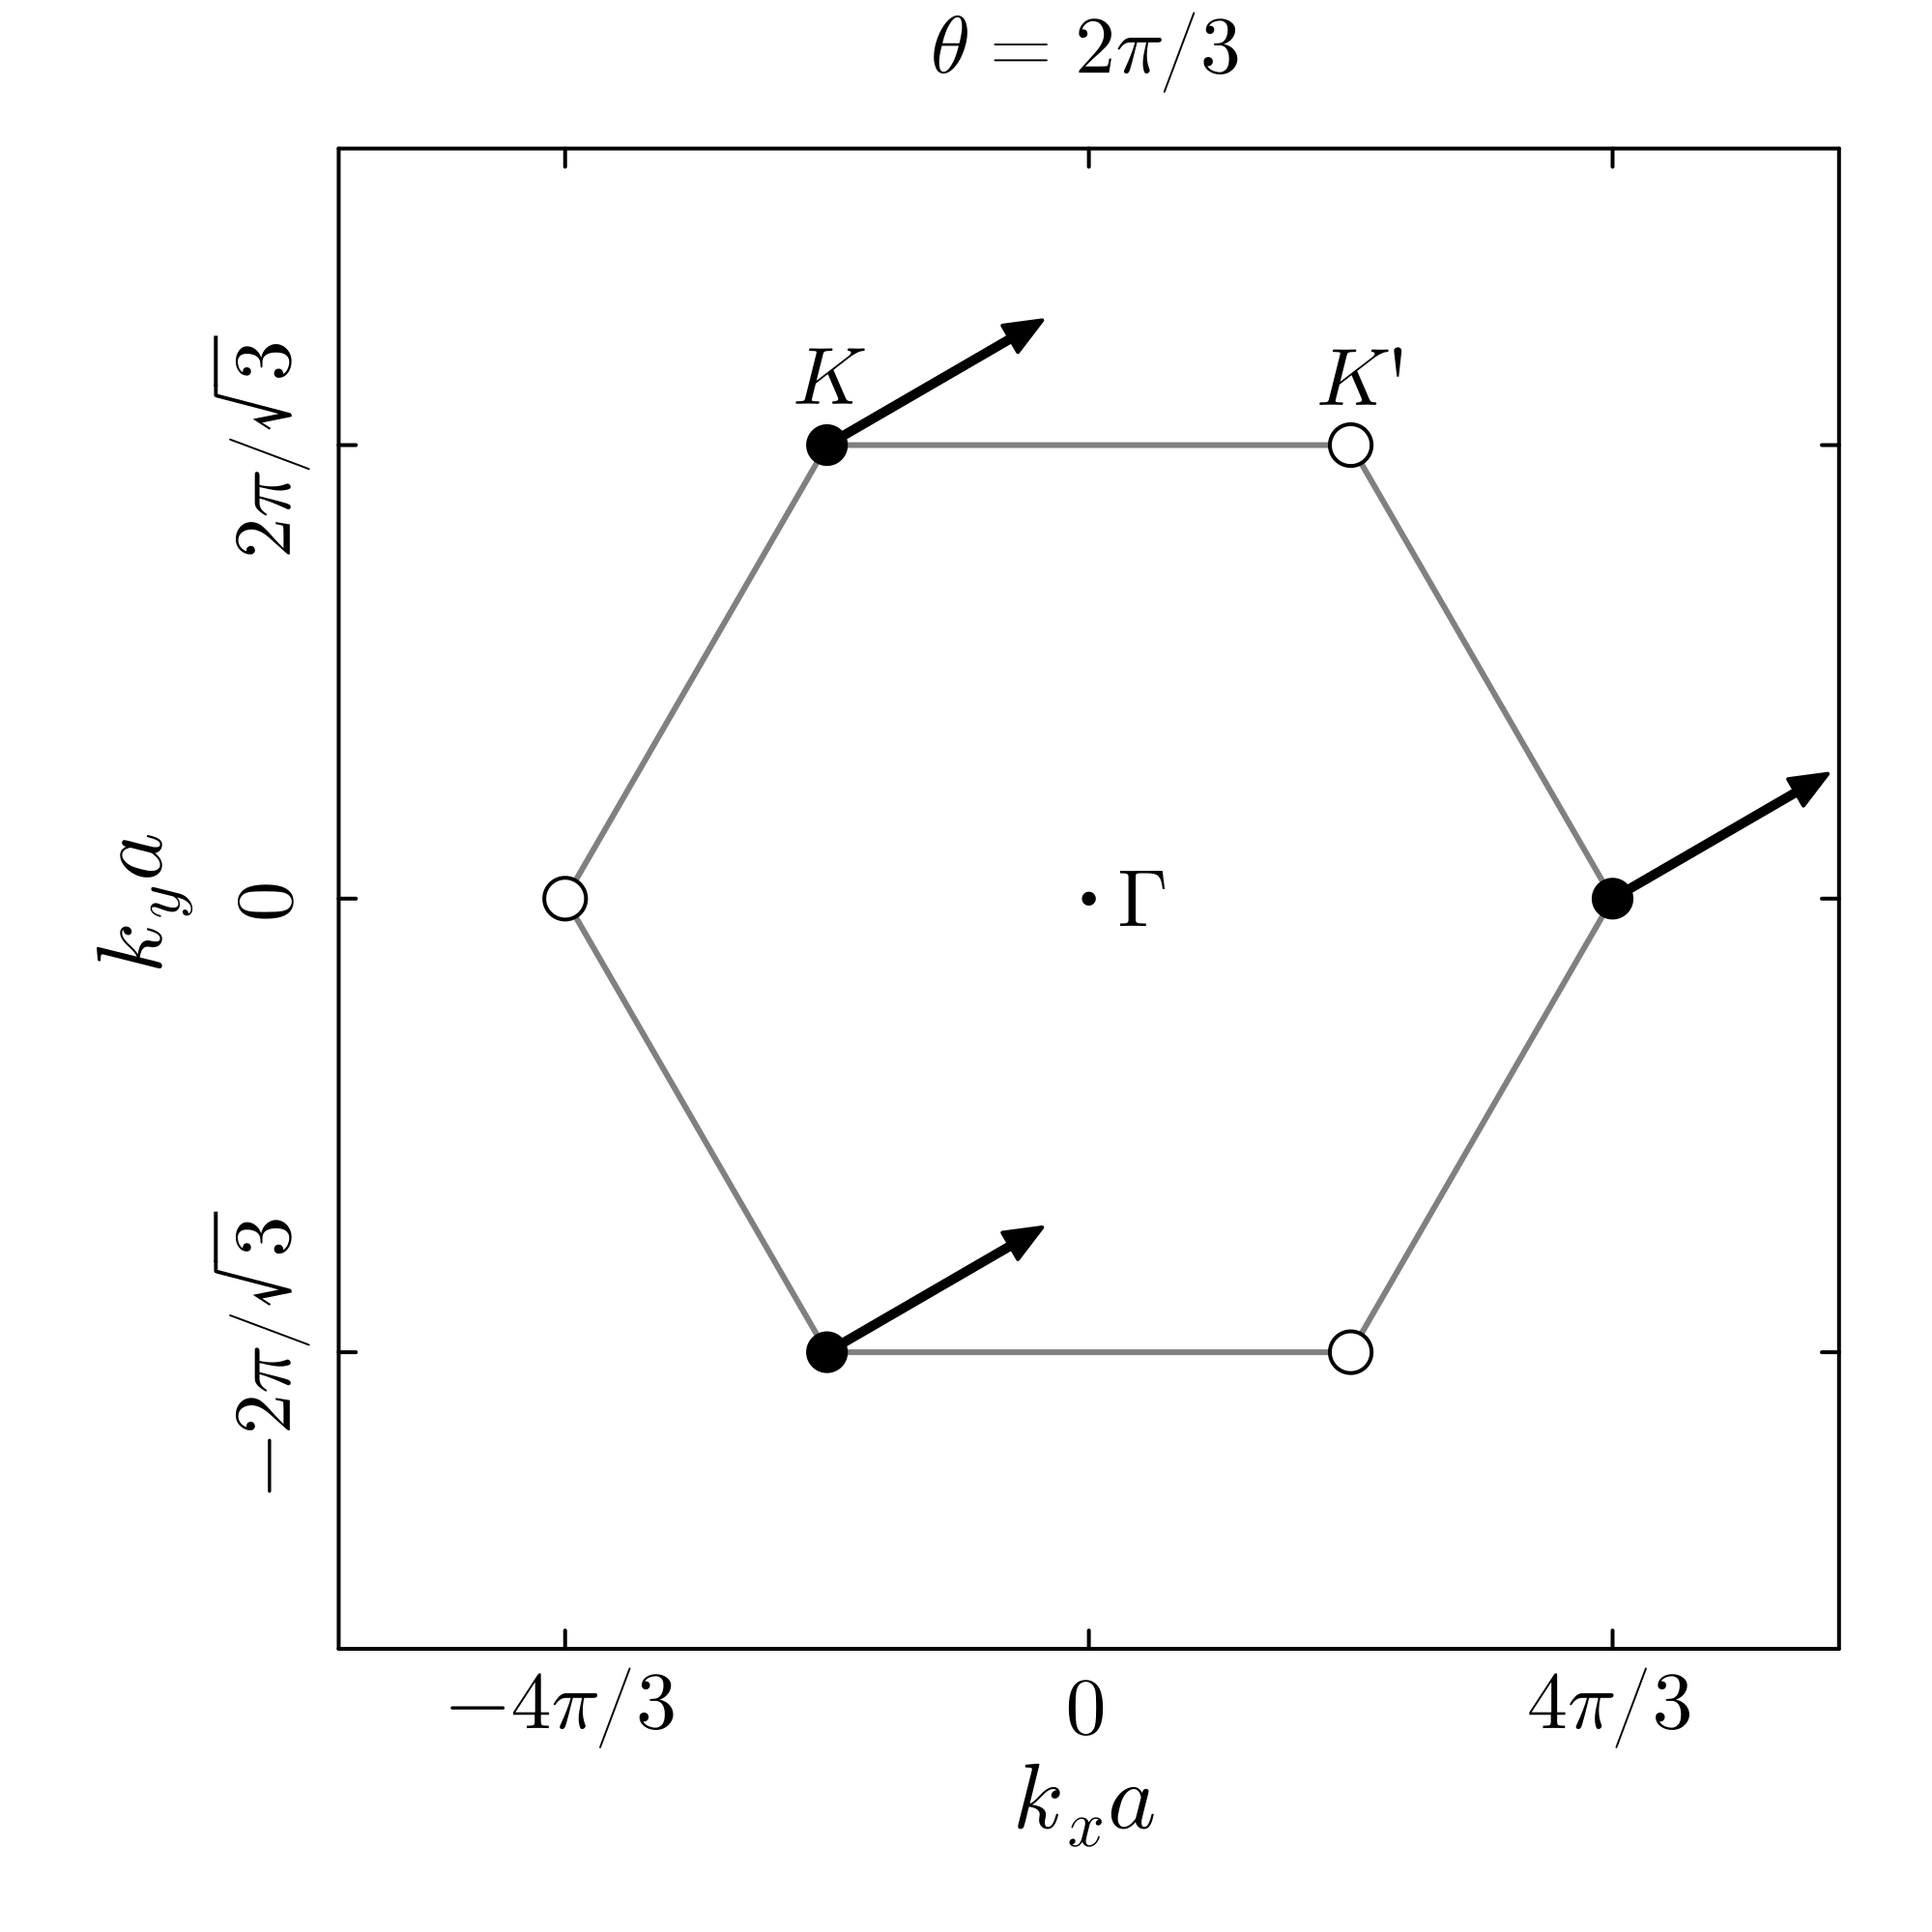

In [5]:
df = CSV.read("figs3_theta_2pi_3.csv", DataFrame)

kx = df.kx_list
ky = df.ky_list
U = df.rx_list
V = df.ry_list;
kx_p=-kx
ky_p=-ky

p = plot(size=(500, 500), aspect_ratio=:equal, dpi=400)

plot!(hex_x, hex_y; lw=1.5, color=:grey, label=false)

# Γ point
scatter!([0.0], [0.0]; markersize=2, markercolor=:black, label=false)
annotate!(0.25, 0.0, text(L"\Gamma", :left, 14))

# shift vectors at K
for i in eachindex(kx)
    draw_custom_arrow!(
        p, kx[i], ky[i], U[i], V[i];
        scale=0.8,
        head_size=0.4,
        color=:black,
        lw=2.5
    )
end

scatter!(kx, ky; markersize=6, markercolor=:black, markerstrokecolor=:black, label=false)
scatter!(kx_p, ky_p; markersize=6, markercolor=:white, markerstrokecolor=:black, label=false)

annotate!(kx[2]-0.25 , ky[2]+0.55 , text(L"K", :left, 14))
annotate!(kx_p[3]-0.25 , ky_p[3] +0.55, text(L"K'", :left, 14))

plot!(
    framestyle=:box,
    grid=false,
    xlims=(-6,6),
    ylims=(-6,6),
    xticks=([-4pi/3,0,4pi/3], [L"-4\pi/3", L"0", L"4\pi/3"]),
    yticks=([-2pi/sqrt(3), 0,  2pi/sqrt(3)], [L"-2\pi/\sqrt{3}",  L"0", L"2\pi/\sqrt{3}"]
),
    tickfontsize=14,
    title=L"\theta=2\pi/3",
    xlabel=L"k_x a",   
    ylabel=L"k_y a",    
    guidefontsize=16,
    yrotation = 90
)

savefig("fig3.pdf")
display(p)